/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

MARKET BASKET ANALYSIS

Total Transactions: 10

Sample Transactions:
Transaction 1: ['Bread', 'Milk', 'Eggs']
Transaction 2: ['Bread', 'Butter', 'Jam']
Transaction 3: ['Milk', 'Bread', 'Butter']

Binary Matrix:
    Bread  Butter  Cereal   Eggs    Jam   Milk
0   True   False   False   True  False   True
1   True    True   False  False   True  False
2   True    True   False  False  False   True
3   True    True   False   True  False   True
4  False   False    True   True  False   True

Item Frequencies:
 Bread     8
Milk      8
Butter    6
Eggs      5
Jam       3
Cereal    2
dtype: int64

Average Items per Transaction: 3.2

APRIORI RESULTS

Frequent Itemsets:
     support               itemsets
0       0.8                (Bread)
1       0.6               (Butter)
2       0.5                 (Eggs)
3       0.3                  (Jam)
4       0.8                 (Milk)
5       0.6        (Butter, Bread)
6       0.3          (Eggs, Bread)
7       0.3           (Jam, Bread)
8       0.6       

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

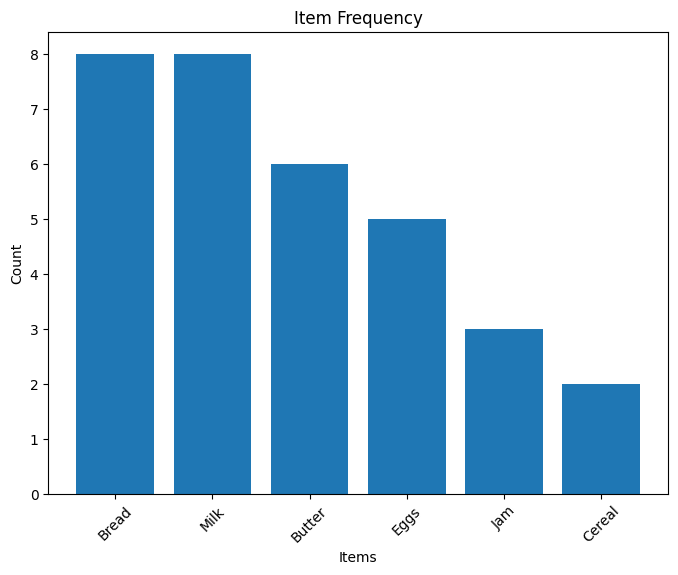

BUSINESS INSIGHTS

• Customers buying certain items tend to buy related items.
• Lift > 1 indicates strong association.
• Can be used for product placement and marketing.

Marketing Suggestions:
1. Place related products together
2. Offer combo discounts
3. Recommend products to customers


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [4]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt

# Part A: Data Preparation

print("="*60)
print("MARKET BASKET ANALYSIS")
print("="*60)

transactions = [
    ['Bread', 'Milk', 'Eggs'],
    ['Bread', 'Butter', 'Jam'],
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Milk', 'Butter', 'Eggs'],
    ['Milk', 'Eggs', 'Cereal'],
    ['Bread', 'Eggs', 'Milk'],
    ['Butter', 'Jam', 'Bread'],
    ['Bread', 'Milk', 'Butter'],
    ['Milk', 'Cereal', 'Eggs'],
    ['Bread', 'Butter', 'Jam', 'Milk']
]

print("\nTotal Transactions:", len(transactions))
print("\nSample Transactions:")
for i in range(3):
    print(f"Transaction {i+1}: {transactions[i]}")


te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_array, columns=te.columns_)

print("\nBinary Matrix:\n", df.head())


item_freq = df.sum().sort_values(ascending=False)
print("\nItem Frequencies:\n", item_freq)

trans_len = [len(t) for t in transactions]
print("\nAverage Items per Transaction:", np.mean(trans_len))

# Part B: Apriori Algorithm

print("\n" + "="*60)
print("APRIORI RESULTS")
print("="*60)

freq_items = apriori(df, min_support=0.3, use_colnames=True)
print("\nFrequent Itemsets:\n", freq_items)

rules = association_rules(freq_items, metric="confidence", min_threshold=0.5)

print("\nAll Rules:\n")
print(rules[['antecedents','consequents','support','confidence','lift']])

strong_rules = rules[rules['lift'] > 1]


# Part C: Results

print("\nStrong Association Rules:\n")
print(strong_rules[['antecedents','consequents','support','confidence','lift']])

top_rules = strong_rules.nlargest(5, 'lift')

print("\nTop 5 Rules by Lift:")
for i, row in top_rules.iterrows():
    print(f"{list(row['antecedents'])} -> {list(row['consequents'])}")
    print(f"Support: {row['support']:.2f}, Confidence: {row['confidence']:.2f}, Lift: {row['lift']:.2f}\n")

plt.figure(figsize=(8,6))
plt.bar(item_freq.index, item_freq.values)
plt.title("Item Frequency")
plt.xlabel("Items")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print("\n• Customers buying certain items tend to buy related items.")
print("• Lift > 1 indicates strong association.")
print("• Can be used for product placement and marketing.")

print("\nMarketing Suggestions:")
print("1. Place related products together")
print("2. Offer combo discounts")
print("3. Recommend products to customers")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


--- Comparison ---
Apriori Itemsets: 15
FP-Growth Itemsets: 15


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

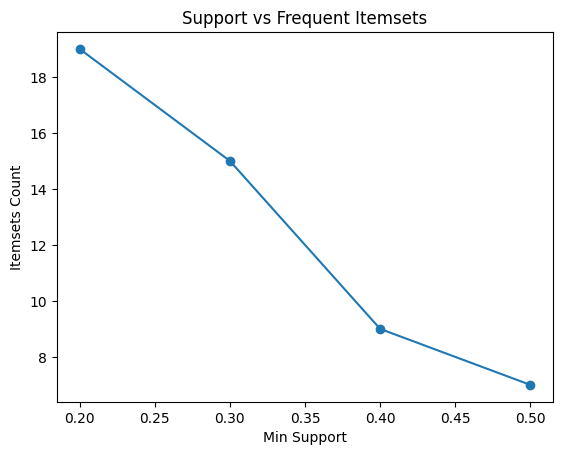

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag


Pruned Rules:

       antecedents      consequents  support  confidence      lift
0         (Butter)          (Bread)      0.6    1.000000  1.250000
1          (Bread)         (Butter)      0.6    0.750000  1.250000
3            (Jam)          (Bread)      0.3    1.000000  1.250000
7            (Jam)         (Butter)      0.3    1.000000  1.666667
10          (Milk)           (Eggs)      0.5    0.625000  1.250000
11          (Eggs)           (Milk)      0.5    1.000000  1.250000
12   (Butter, Jam)          (Bread)      0.3    1.000000  1.250000
14    (Jam, Bread)         (Butter)      0.3    1.000000  1.666667
16           (Jam)  (Butter, Bread)      0.3    1.000000  1.666667
17  (Milk, Butter)          (Bread)      0.4    1.000000  1.250000
18   (Milk, Bread)         (Butter)      0.4    0.666667  1.111111
21        (Butter)    (Milk, Bread)      0.4    0.666667  1.111111
25   (Eggs, Bread)           (Milk)      0.3    1.000000  1.250000

Medical Domain Rules:

  antecedents conseque

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

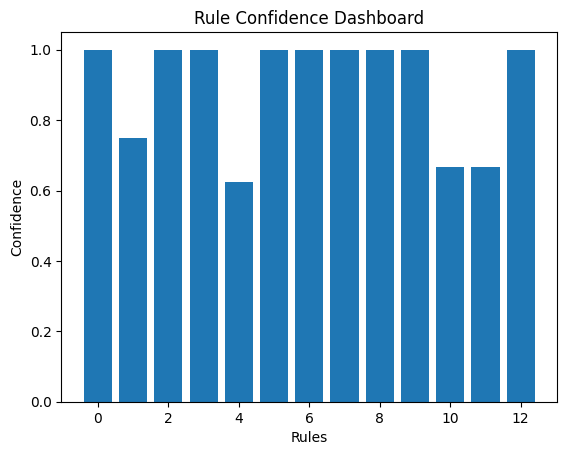

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [5]:
# Extended Experiment: Association Rule Mining

import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules


transactions = [
    ['Bread','Milk','Eggs'],
    ['Bread','Butter','Jam'],
    ['Milk','Bread','Butter'],
    ['Bread','Milk','Butter','Eggs'],
    ['Milk','Eggs','Cereal'],
    ['Bread','Eggs','Milk'],
    ['Butter','Jam','Bread'],
    ['Bread','Milk','Butter'],
    ['Milk','Cereal','Eggs'],
    ['Bread','Butter','Jam','Milk']
]

te = TransactionEncoder()
df = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)

apriori_items = apriori(df, min_support=0.3, use_colnames=True)
apriori_rules = association_rules(apriori_items, metric="confidence", min_threshold=0.5)

fp_items = fpgrowth(df, min_support=0.3, use_colnames=True)
fp_rules = association_rules(fp_items, metric="confidence", min_threshold=0.5)

print("\n--- Comparison ---")
print("Apriori Itemsets:", len(apriori_items))
print("FP-Growth Itemsets:", len(fp_items))

supports = [0.2, 0.3, 0.4, 0.5]
counts = []

for s in supports:
    items = apriori(df, min_support=s, use_colnames=True)
    counts.append(len(items))

plt.plot(supports, counts, marker='o')
plt.title("Support vs Frequent Itemsets")
plt.xlabel("Min Support")
plt.ylabel("Itemsets Count")
plt.show()

rules = apriori_rules
pruned_rules = rules[(rules['confidence'] > 0.6) & (rules['lift'] > 1)]

print("\nPruned Rules:\n")
print(pruned_rules[['antecedents','consequents','support','confidence','lift']])

medical_data = [
    ['Fever','Cough'],
    ['Fever','Cold'],
    ['Cough','Cold'],
    ['Fever','Cough','Cold']
]

df2 = pd.DataFrame(te.fit(medical_data).transform(medical_data), columns=te.columns_)

med_items = apriori(df2, min_support=0.5, use_colnames=True)
med_rules = association_rules(med_items, metric="confidence", min_threshold=0.6)

print("\nMedical Domain Rules:\n")
print(med_rules[['antecedents','consequents','support','confidence']])

plt.bar(range(len(pruned_rules)), pruned_rules['confidence'])
plt.title("Rule Confidence Dashboard")
plt.xlabel("Rules")
plt.ylabel("Confidence")
plt.show()